<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Academic_Salaries_in_the_US.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

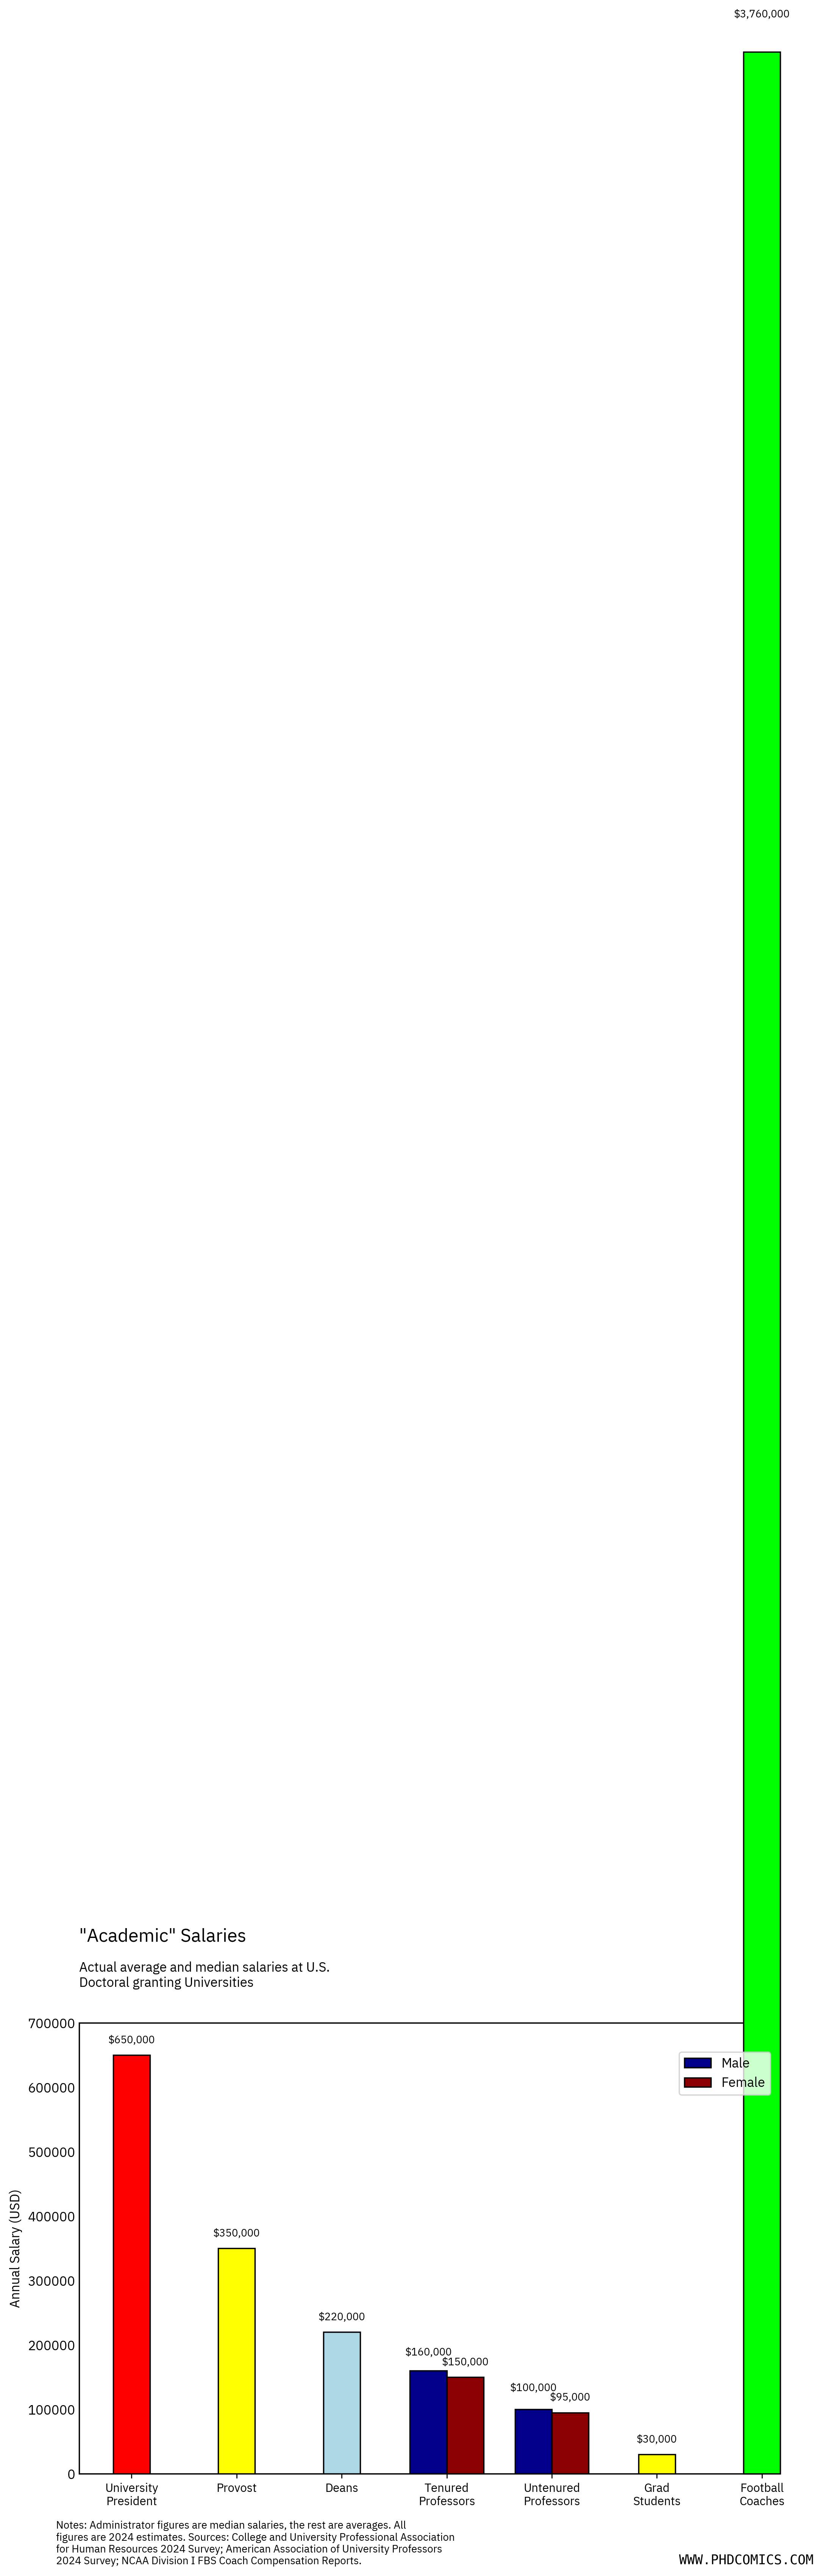

In [21]:
"""
Generation of a decompressed, scale-accurate academic compensation visualization.

This Python script adheres to Python Enhancement Proposal (PEP) 8
and PEP 257 standards. Adapted from PhD Comics.
"""

import os
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# CONTROL KNOBS
# =============================================================================
PLOT_RESOLUTION_DPI = 250
Y_AXIS_VISUAL_LIMIT = 700000

# Dramatically expanded vertical dimensions to prevent coordinate compression
FIGURE_HEIGHT_INCHES = 28
FIGURE_AXES_TOP = 0.22      # Allocates 78% of the massive canvas for the coach bar
FIGURE_AXES_BOTTOM = 0.05   # Bottom bound providing ample space for citations

# Average 2024 salary estimates expressed in United States Dollars (USD)
SALARY_PRESIDENT = 650000
SALARY_PROVOST = 350000
SALARY_DEAN = 220000
SALARY_TENURED_MALE = 160000
SALARY_TENURED_FEMALE = 150000
SALARY_UNTENURED_MALE = 100000
SALARY_UNTENURED_FEMALE = 95000
SALARY_GRAD_STUDENT = 30000
SALARY_COACH_ACTUAL = 3760000

# Visual properties
COLOR_EXEC = 'red'
COLOR_PROVOST = 'yellow'
COLOR_DEAN = 'lightblue'
COLOR_MALE = 'darkblue'
COLOR_FEMALE = 'darkred'
COLOR_GRAD = 'yellow'
COLOR_COACH = 'lime'
# =============================================================================

def configure_custom_typography():
    """
    Download and configure the IBM Plex Sans TrueType Font dynamically.
    """
    font_url = (
        "https://raw.githubusercontent.com/IBM/plex/master/"
        "packages/plex-sans/fonts/complete/ttf/IBMPlexSans-Regular.ttf"
    )
    font_path = "/tmp/IBMPlexSans-Regular.ttf"

    if not os.path.exists(font_path):
        request = urllib.request.Request(
            font_url,
            headers={'User-Agent': 'Mozilla/5.0'}
        )
        with urllib.request.urlopen(request) as response:
            with open(font_path, 'wb') as font_file:
                font_file.write(response.read())

    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'IBM Plex Sans'

def render_salary_plot():
    """
    Construct and display the refined academic compensation visualization.
    """
    configure_custom_typography()
    plt.rcParams['figure.dpi'] = PLOT_RESOLUTION_DPI

    # Instantiate the massively expanded canvas geometry
    figure, axis = plt.subplots(figsize=(10, FIGURE_HEIGHT_INCHES))
    plt.subplots_adjust(top=FIGURE_AXES_TOP, bottom=FIGURE_AXES_BOTTOM)

    positions = np.arange(7)
    bar_width = 0.35

    # Standard academic graphical columns
    axis.bar(positions[0], SALARY_PRESIDENT, bar_width, color=COLOR_EXEC, edgecolor='black')
    axis.bar(positions[1], SALARY_PROVOST, bar_width, color=COLOR_PROVOST, edgecolor='black')
    axis.bar(positions[2], SALARY_DEAN, bar_width, color=COLOR_DEAN, edgecolor='black')

    axis.bar(positions[3] - bar_width/2, SALARY_TENURED_MALE, bar_width, color=COLOR_MALE, edgecolor='black', label='Male')
    axis.bar(positions[3] + bar_width/2, SALARY_TENURED_FEMALE, bar_width, color=COLOR_FEMALE, edgecolor='black', label='Female')

    axis.bar(positions[4] - bar_width/2, SALARY_UNTENURED_MALE, bar_width, color=COLOR_MALE, edgecolor='black')
    axis.bar(positions[4] + bar_width/2, SALARY_UNTENURED_FEMALE, bar_width, color=COLOR_FEMALE, edgecolor='black')

    axis.bar(positions[5], SALARY_GRAD_STUDENT, bar_width, color=COLOR_GRAD, edgecolor='black')

    # Coach column utilizing the mathematically accurate numeric value
    axis.bar(
        positions[6],
        SALARY_COACH_ACTUAL,
        bar_width,
        color=COLOR_COACH,
        edgecolor='black',
        clip_on=False
    )

    def add_label(x_coord, y_coord, value, y_offset=15000):
        """Append a formatted currency string above a specific column with a modular offset."""
        axis.text(x_coord, y_coord + y_offset, f'${value:,}', ha='center', va='bottom', fontsize=8)

    add_label(positions[0], SALARY_PRESIDENT, SALARY_PRESIDENT)
    add_label(positions[1], SALARY_PROVOST, SALARY_PROVOST)
    add_label(positions[2], SALARY_DEAN, SALARY_DEAN)

    # Elevate the male annotations to preserve typographical clarity in the decompressed grid
    add_label(positions[3] - bar_width/2, SALARY_TENURED_MALE, SALARY_TENURED_MALE, y_offset=20000)
    add_label(positions[3] + bar_width/2, SALARY_TENURED_FEMALE, SALARY_TENURED_FEMALE)

    add_label(positions[4] - bar_width/2, SALARY_UNTENURED_MALE, SALARY_UNTENURED_MALE, y_offset=25000)
    add_label(positions[4] + bar_width/2, SALARY_UNTENURED_FEMALE, SALARY_UNTENURED_FEMALE)

    add_label(positions[5], SALARY_GRAD_STUDENT, SALARY_GRAD_STUDENT)

    # Place the athletic label at the apex of the extended column
    axis.text(
        positions[6],
        SALARY_COACH_ACTUAL + 50000,
        f'${SALARY_COACH_ACTUAL:,}',
        ha='center',
        va='bottom',
        fontsize=8,
        clip_on=False
    )

    axis.set_ylim(0, Y_AXIS_VISUAL_LIMIT)
    axis.set_xticks(positions)
    labels = [
        'University\nPresident', 'Provost', 'Deans',
        'Tenured\nProfessors', 'Untenured\nProfessors',
        'Grad\nStudents', 'Football\nCoaches'
    ]
    axis.set_xticklabels(labels, fontsize=9)
    axis.set_ylabel('Annual Salary (USD)')

    # Draw an explicit framing box to emulate the original aesthetic
    framing_box = plt.Rectangle(
        (-0.5, 0), 6.5, Y_AXIS_VISUAL_LIMIT,
        fill=False, edgecolor='black', linewidth=1, zorder=0, clip_on=False
    )
    axis.add_patch(framing_box)

    # Remove standard spines to favor the custom framing box
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_visible(False)
    axis.spines['bottom'].set_visible(False)

    axis.tick_params(axis='y', length=0)

    # Title positioning shifted vertically by one additional linespace
    axis.text(-0.5, Y_AXIS_VISUAL_LIMIT * 1.18, '"Academic" Salaries', fontsize=14, fontweight='bold', ha='left', clip_on=False)
    axis.text(-0.5, Y_AXIS_VISUAL_LIMIT * 1.08, 'Actual average and median salaries at U.S.\nDoctoral granting Universities', fontsize=10, ha='left', clip_on=False)

    axis.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))

    # Render the detailed methodological notes and statistical sources
    methodology_text = (
        "Notes: Administrator figures are median salaries, the rest are averages. All\n"
        "figures are 2024 estimates. Sources: College and University Professional Association\n"
        "for Human Resources 2024 Survey; American Association of University Professors\n"
        "2024 Survey; NCAA Division I FBS Coach Compensation Reports."
    )

    plt.figtext(
        0.1, 0.015,
        methodology_text,
        fontsize=8, ha='left', va='bottom', wrap=True
    )

    plt.figtext(
        0.9, 0.015,
        "WWW.PHDCOMICS.COM",
        fontsize=10, ha='right', va='bottom', fontname='monospace'
    )

    plt.show()

if __name__ == '__main__':
    render_salary_plot()

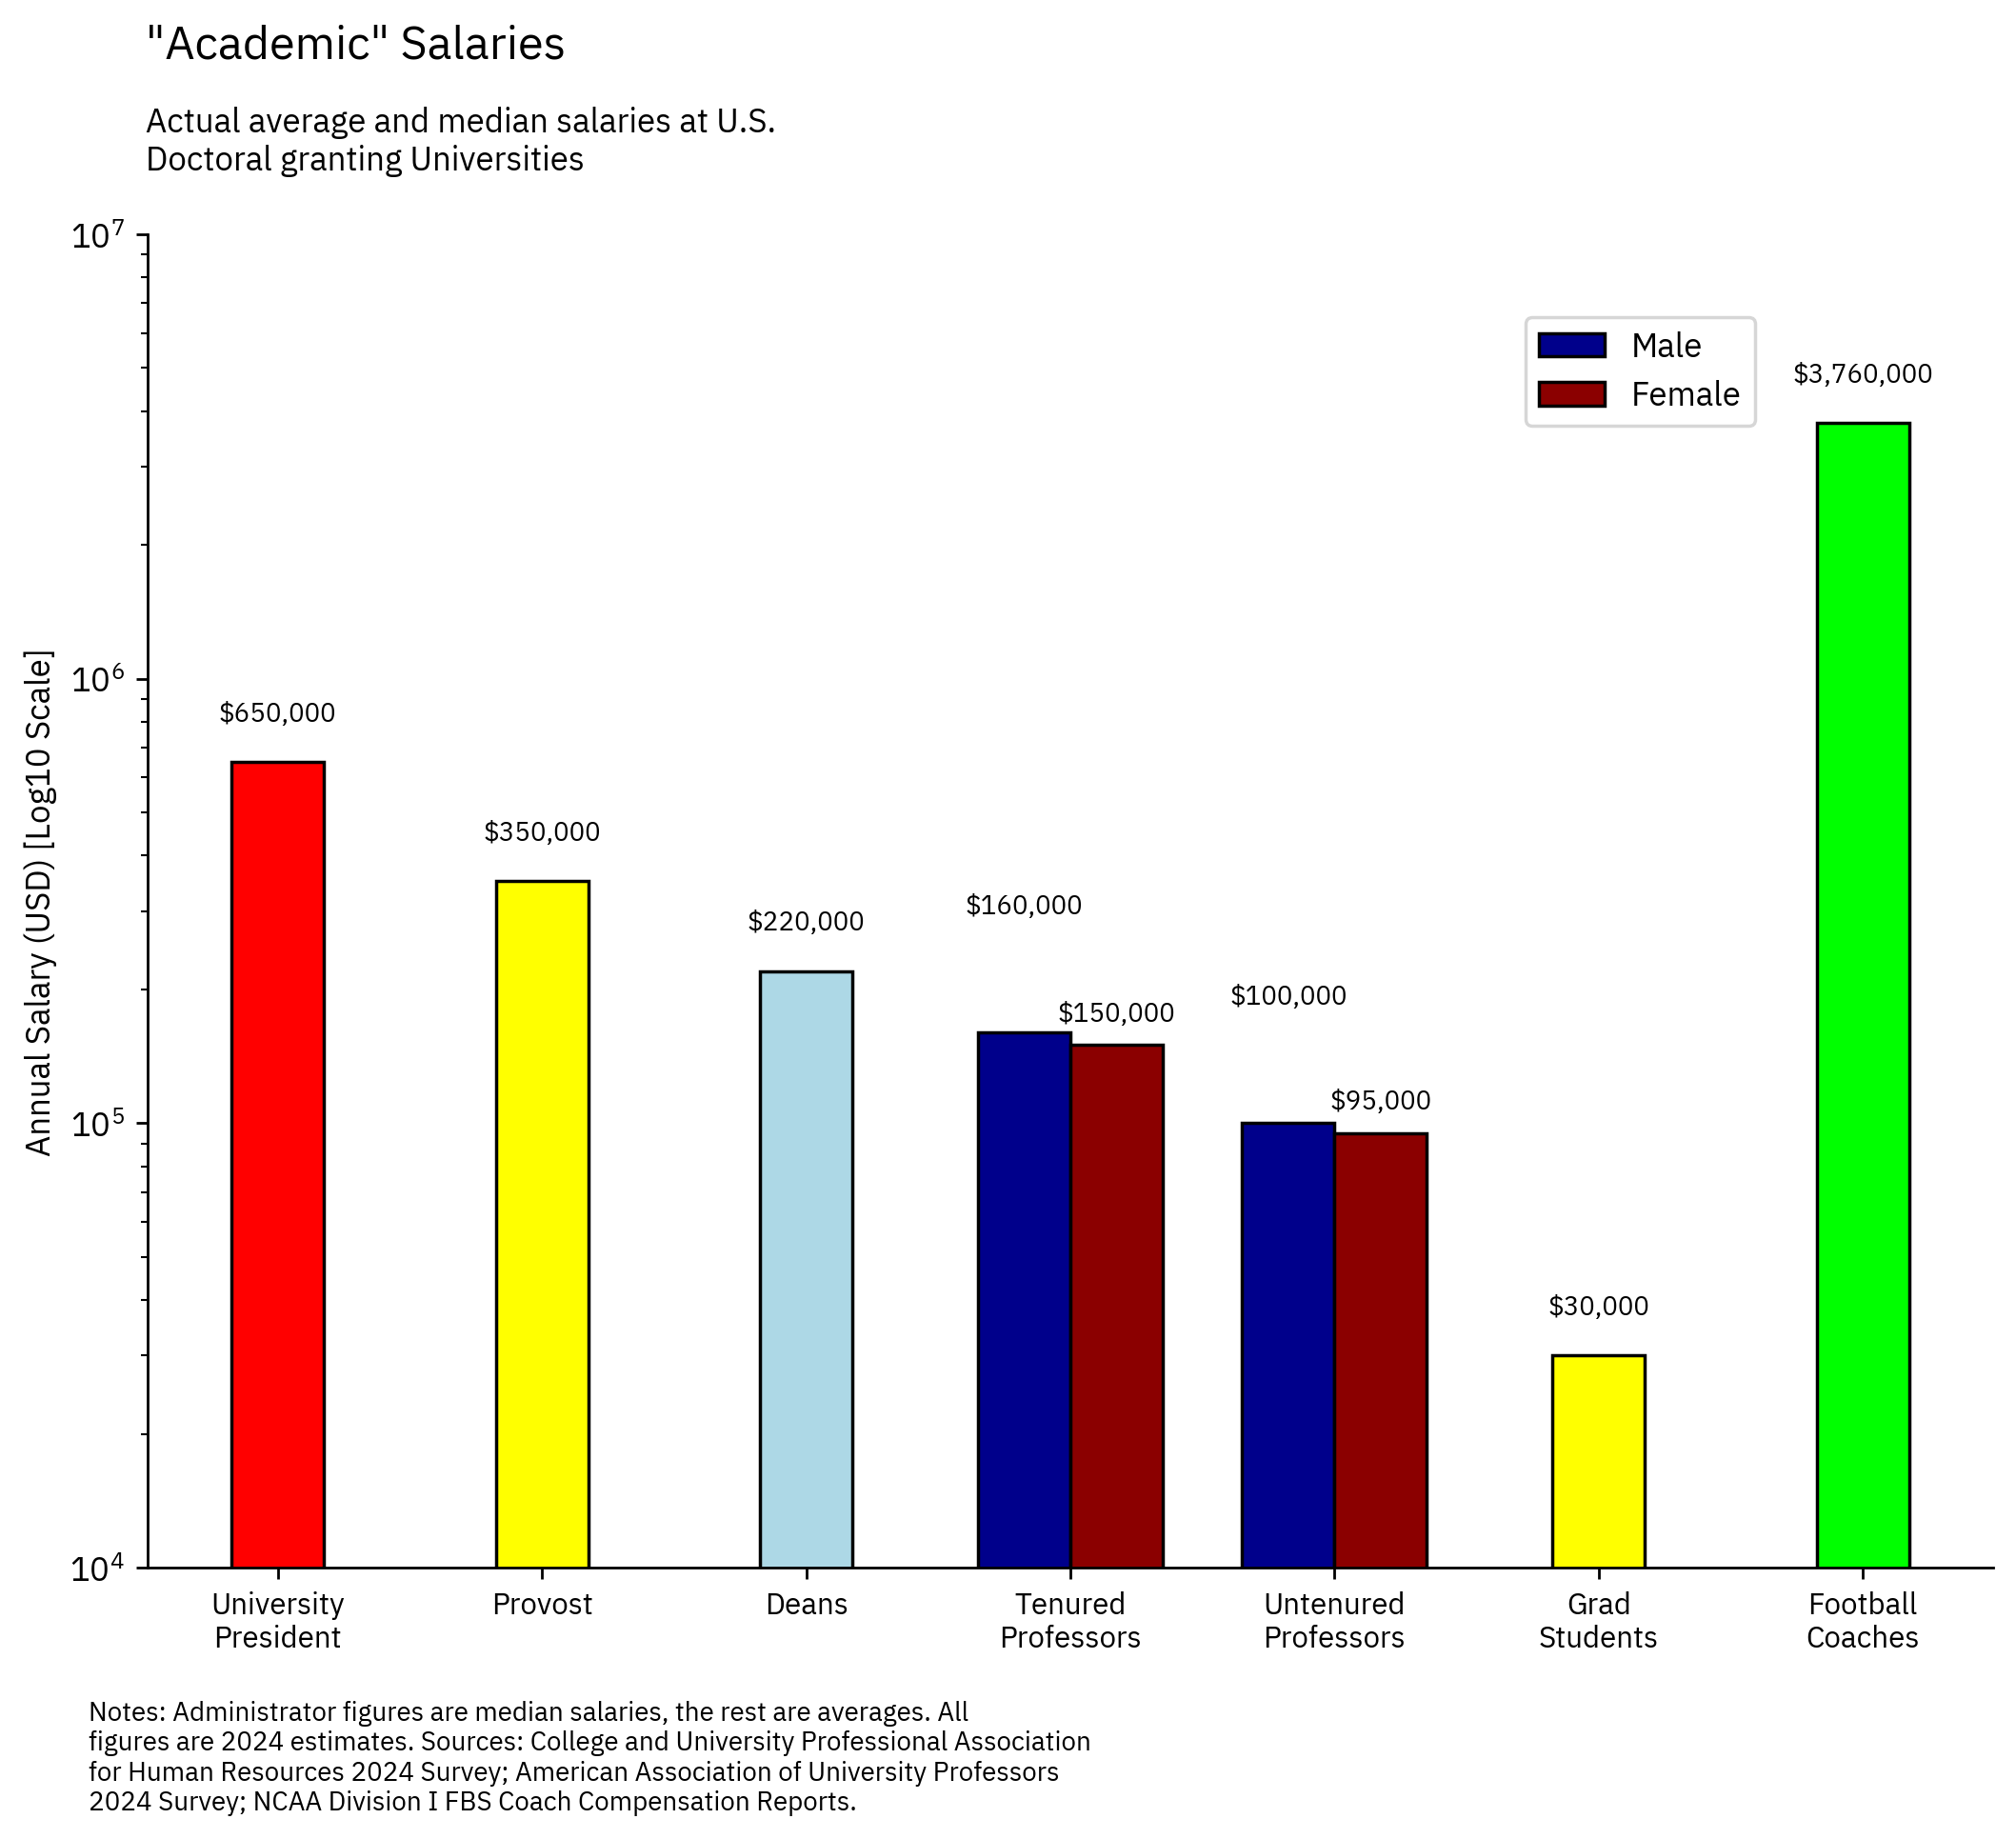

In [22]:
"""
Generation of a base-10 logarithmic academic compensation visualization.

This Python script adheres to Python Enhancement Proposal (PEP) 8
and PEP 257 standards.
"""

import os
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# CONTROL KNOBS
# =============================================================================
PLOT_RESOLUTION_DPI = 250

# Standardized layout parameters optimized for logarithmic compression
FIGURE_HEIGHT_INCHES = 8
FIGURE_AXES_TOP = 0.85
FIGURE_AXES_BOTTOM = 0.15

# Logarithmic scaling boundaries (United States Dollars)
LOG_AXIS_MINIMUM = 10000
LOG_AXIS_MAXIMUM = 10000000

# Average 2024 salary estimates expressed in United States Dollars (USD)
SALARY_PRESIDENT = 650000
SALARY_PROVOST = 350000
SALARY_DEAN = 220000
SALARY_TENURED_MALE = 160000
SALARY_TENURED_FEMALE = 150000
SALARY_UNTENURED_MALE = 100000
SALARY_UNTENURED_FEMALE = 95000
SALARY_GRAD_STUDENT = 30000
SALARY_COACH_ACTUAL = 3760000

# Visual properties
COLOR_EXEC = 'red'
COLOR_PROVOST = 'yellow'
COLOR_DEAN = 'lightblue'
COLOR_MALE = 'darkblue'
COLOR_FEMALE = 'darkred'
COLOR_GRAD = 'yellow'
COLOR_COACH = 'lime'
# =============================================================================

def configure_custom_typography():
    """
    Download and configure the IBM Plex Sans TrueType Font dynamically.
    """
    font_url = (
        "https://raw.githubusercontent.com/IBM/plex/master/"
        "packages/plex-sans/fonts/complete/ttf/IBMPlexSans-Regular.ttf"
    )
    font_path = "/tmp/IBMPlexSans-Regular.ttf"

    if not os.path.exists(font_path):
        request = urllib.request.Request(
            font_url,
            headers={'User-Agent': 'Mozilla/5.0'}
        )
        with urllib.request.urlopen(request) as response:
            with open(font_path, 'wb') as font_file:
                font_file.write(response.read())

    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'IBM Plex Sans'

def render_salary_plot():
    """
    Construct and display the logarithmic academic compensation visualization.
    """
    configure_custom_typography()
    plt.rcParams['figure.dpi'] = PLOT_RESOLUTION_DPI

    figure, axis = plt.subplots(figsize=(10, FIGURE_HEIGHT_INCHES))
    plt.subplots_adjust(top=FIGURE_AXES_TOP, bottom=FIGURE_AXES_BOTTOM)

    positions = np.arange(7)
    bar_width = 0.35

    # Standard academic graphical columns
    axis.bar(positions[0], SALARY_PRESIDENT, bar_width, color=COLOR_EXEC, edgecolor='black')
    axis.bar(positions[1], SALARY_PROVOST, bar_width, color=COLOR_PROVOST, edgecolor='black')
    axis.bar(positions[2], SALARY_DEAN, bar_width, color=COLOR_DEAN, edgecolor='black')

    axis.bar(positions[3] - bar_width/2, SALARY_TENURED_MALE, bar_width, color=COLOR_MALE, edgecolor='black', label='Male')
    axis.bar(positions[3] + bar_width/2, SALARY_TENURED_FEMALE, bar_width, color=COLOR_FEMALE, edgecolor='black', label='Female')

    axis.bar(positions[4] - bar_width/2, SALARY_UNTENURED_MALE, bar_width, color=COLOR_MALE, edgecolor='black')
    axis.bar(positions[4] + bar_width/2, SALARY_UNTENURED_FEMALE, bar_width, color=COLOR_FEMALE, edgecolor='black')

    axis.bar(positions[5], SALARY_GRAD_STUDENT, bar_width, color=COLOR_GRAD, edgecolor='black')
    axis.bar(positions[6], SALARY_COACH_ACTUAL, bar_width, color=COLOR_COACH, edgecolor='black')

    # Mathematical transformation to a base ten logarithmic coordinate system
    axis.set_yscale('log')
    axis.set_ylim(LOG_AXIS_MINIMUM, LOG_AXIS_MAXIMUM)

    def add_label_logarithmic(x_coord, y_coord, value, y_multiplier=1.2):
        """Append a formatted string using multiplicative scalar offsets."""
        axis.text(x_coord, y_coord * y_multiplier, f'${value:,}', ha='center', va='bottom', fontsize=8)

    add_label_logarithmic(positions[0], SALARY_PRESIDENT, SALARY_PRESIDENT)
    add_label_logarithmic(positions[1], SALARY_PROVOST, SALARY_PROVOST)
    add_label_logarithmic(positions[2], SALARY_DEAN, SALARY_DEAN)

    # Elevate the male annotations via a higher scalar multiplier to preserve clarity
    add_label_logarithmic(positions[3] - bar_width/2, SALARY_TENURED_MALE, SALARY_TENURED_MALE, y_multiplier=1.8)
    add_label_logarithmic(positions[3] + bar_width/2, SALARY_TENURED_FEMALE, SALARY_TENURED_FEMALE, y_multiplier=1.1)

    add_label_logarithmic(positions[4] - bar_width/2, SALARY_UNTENURED_MALE, SALARY_UNTENURED_MALE, y_multiplier=1.8)
    add_label_logarithmic(positions[4] + bar_width/2, SALARY_UNTENURED_FEMALE, SALARY_UNTENURED_FEMALE, y_multiplier=1.1)

    add_label_logarithmic(positions[5], SALARY_GRAD_STUDENT, SALARY_GRAD_STUDENT)
    add_label_logarithmic(positions[6], SALARY_COACH_ACTUAL, SALARY_COACH_ACTUAL)

    axis.set_xticks(positions)
    labels = [
        'University\nPresident', 'Provost', 'Deans',
        'Tenured\nProfessors', 'Untenured\nProfessors',
        'Grad\nStudents', 'Football\nCoaches'
    ]
    axis.set_xticklabels(labels, fontsize=9)
    axis.set_ylabel('Annual Salary (USD) [Log10 Scale]')

    # Standardize the boundary spines for a clean logarithmic presentation
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_visible(True)
    axis.spines['bottom'].set_visible(True)

    # Title positioning utilizes exponential mathematical offsets relative to the maximum
    axis.text(-0.5, LOG_AXIS_MAXIMUM * 2.5, '"Academic" Salaries', fontsize=14, fontweight='bold', ha='left', clip_on=False)
    axis.text(-0.5, LOG_AXIS_MAXIMUM * 1.4, 'Actual average and median salaries at U.S.\nDoctoral granting Universities', fontsize=10, ha='left', clip_on=False)

    # LEGEND ADJUSTMENT: Decreased x-coordinate from 0.95 to 0.88 to move left
    axis.legend(loc='upper right', bbox_to_anchor=(0.88, 0.95))

    # Render the detailed methodological notes and statistical sources
    methodology_text = (
        "Notes: Administrator figures are median salaries, the rest are averages. All\n"
        "figures are 2024 estimates. Sources: College and University Professional Association\n"
        "for Human Resources 2024 Survey; American Association of University Professors\n"
        "2024 Survey; NCAA Division I FBS Coach Compensation Reports."
    )

    plt.figtext(
        0.1, 0.02,
        methodology_text,
        fontsize=8, ha='left', va='bottom', wrap=True
    )

    plt.show()

if __name__ == '__main__':
    render_salary_plot()